# Formulas
## Change in susceptible resistant ratio
$\frac{d(Cells_{S/R})}{dt}=(GR_{S/R}-DR_{S/R})*Cells_{S/R}$

This describes the change in ratio of S to R cells/time

$ TotalCells = Cells_{S}+Cells_{R}$

$\frac{E_{max_{S/R}}}{2}$

$C_s(t)=C_{0,s}(e^{g_st}-e^{d_st}) / C_r(t)=C_{0,r}(e^{g_rt}-e^{d_rt})$

is this the same as: $\frac{d(Cells_{S/R})}{dt}=(GR_{S/R}-DR_{S/R})*Cells_{S/R}$

$F=\frac{C_{0,s}}{C_{0,r}}
=
\frac{e^{g_st}}{e^{g_rt}}$

$\frac{
\left(e^{g_rt}\right)\left(g_se^{g_st}\right)
-
\left(e^{g_st}\right)\left(g_re^{g_rt}\right)
}
{\left(e^{g_rt}\right)^2}$

Simplify:

$=\frac{
g_se^{(g_s+g_r)t}
-
g_re^{(g_s+g_r)t}
}
{\left(e^{g_rt}\right)^2}$

$=\frac{
e^{(g_s+g_r)t}(g_s-g_r)
}
{e^{2g_rt}}$

$=
e^{(g_s+g_r)t-2g_rt}
= e^{(g_s-g_r)t}$

$
\boxed{
(g_s-g_r)e^{(g_s-g_r)t}}$

In [186]:
def dCellsSR_dt(GR, DR, Cells):
    return (GR-DR)*Cells

In [187]:
GR = 23
DR = 14
Cells = 250
dCellsSR_dt(GR, DR, Cells)

2250

In [188]:
growth_rate_resistant = 0.01 # units - hour^-1

def my_ode(resistant_cells):
    dResistant = resistant_cells * growth_rate_resistant
    return dResistant

In [189]:
resistant_cells = 100
print(f"We are starting with {resistant_cells} cells")

for hour in range(24):
    change_in_resistant_cells = my_ode(resistant_cells)
    resistant_cells += change_in_resistant_cells
    print(f"After hour {hour + 1}, we have {round(resistant_cells, 2)} cells")

We are starting with 100 cells
After hour 1, we have 101.0 cells
After hour 2, we have 102.01 cells
After hour 3, we have 103.03 cells
After hour 4, we have 104.06 cells
After hour 5, we have 105.1 cells
After hour 6, we have 106.15 cells
After hour 7, we have 107.21 cells
After hour 8, we have 108.29 cells
After hour 9, we have 109.37 cells
After hour 10, we have 110.46 cells
After hour 11, we have 111.57 cells
After hour 12, we have 112.68 cells
After hour 13, we have 113.81 cells
After hour 14, we have 114.95 cells
After hour 15, we have 116.1 cells
After hour 16, we have 117.26 cells
After hour 17, we have 118.43 cells
After hour 18, we have 119.61 cells
After hour 19, we have 120.81 cells
After hour 20, we have 122.02 cells
After hour 21, we have 123.24 cells
After hour 22, we have 124.47 cells
After hour 23, we have 125.72 cells
After hour 24, we have 126.97 cells


In [190]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [191]:
Sensitive_ode_idx = 0
Resistant_ode_idx = 1

idx_final = -1

In [197]:
def plot_cell_counts(cancer_cells):
    """
    Plot sensitive and resistant cell counts over time from a CancerCells object.

    Parameters
    ----------
    cancer_cells : CancerCells
        A CancerCells instance that has been run with one or more elapse() calls.
    """
    if not cancer_cells.history:
        raise ValueError("No simulation history found.")

    records = []
    cumulative_time = 0.0

    for segment in cancer_cells.history:
        t = segment["time"] + cumulative_time
        sol = segment["sol"]

        for time, (sensitive, resistant) in zip(t, sol):
            total_cells = sensitive + resistant
            
            records.append({
                "Time (hours)": time,
                "Cell count": sensitive,
                "Cell type": "Sensitive",
                "Phase": segment["label"],
            })
            records.append({
                "Time (hours)": time,
                "Cell count": resistant,
                "Cell type": "Resistant",
                "Phase": segment["label"],
            }) 
            records.append({
                "Time (hours)": time,
                "Cell count": total_cells,
                "Cell type": "Total",
                "Phase": segment["label"],
            })    

        cumulative_time = t[-1]

    df = pd.DataFrame(records)

    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=df,
        x="Time (hours)",
        y="Cell count",
        hue="Cell type",
        palette={
            "Sensitive": "blue",
            "Resistant": "red",
            "Total": "black"
        },
        linewidth=2,
    )

    plt.xlabel("Time (hours)")
    plt.ylabel("Cell count")
    plt.title("Sensitive and Resistant Cells Over Time")
    plt.tight_layout()
    plt.show()

In [233]:
class CancerCells:
    def __init__(
        self,
       
        growth_rate_r, # hr^-1 !!!! WARNING make sure actual units make sense
        death_rate_r,  # hr^-1 !!!!

        initial_resistant_cells = 5,
        initial_sensitive_cells = 95,
       
        log = True,
    ):
        self.growth_rate_r = growth_rate_r
        self.death_rate_r = death_rate_r

        self.sensitive_cells = initial_sensitive_cells
        self.resistant_cells = initial_resistant_cells
       
        self.history = []
        self.log = log

    def elapse(self, label: str, duration_h: float):
        if self.log:
            print(f"Running {label} for {duration_h} hours")


        y0 = [self.sensitive_cells, self.resistant_cells]
        minute_resolution = max(int(duration_h * 60), 2) # minute_resolution = int(duration_h * 60)
        t = np.linspace(0, duration_h, minute_resolution)
        sol = odeint(self._ode, y0, t)

        self.sensitive_cells = max(sol[idx_final, Sensitive_ode_idx], 0)
        self.resistant_cells = max(sol[idx_final, Resistant_ode_idx], 0)
       
        Sensitive_initial = sol[0, Sensitive_ode_idx]
        Resistant_initial = sol[0, Resistant_ode_idx]

        self.history.append({
            'label': label,
            'time': t,
            'sol': sol,
            "Sensitive_cells": self.sensitive_cells,
            "Resistant_cells": self.resistant_cells,
            "change_in_sensitive_cells": self.sensitive_cells - Sensitive_initial,
        })


    def _ode(self, y, t):
        sensitive_cells, resistant_cells = y
       
        dSensitive = 0
        dResistant = resistant_cells * self.growth_rate_r - resistant_cells * self.death_rate_r

        return [dSensitive, dResistant]

In [237]:
cancer_cells = CancerCells(growth_rate_r=0.041, death_rate_r=0.011)

In [238]:
cancer_cells.elapse("Initial run", 24)

Running Initial run for 24 hours


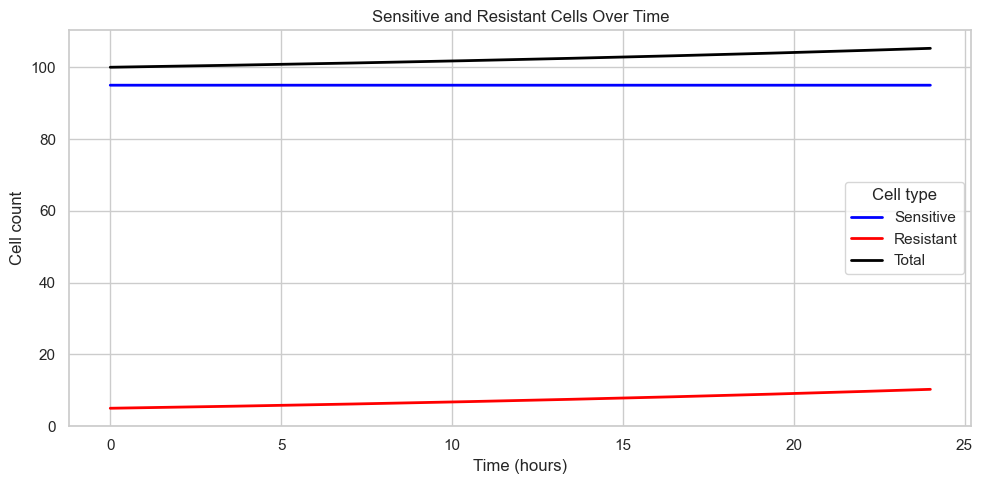

In [239]:
plot_cell_counts(cancer_cells)

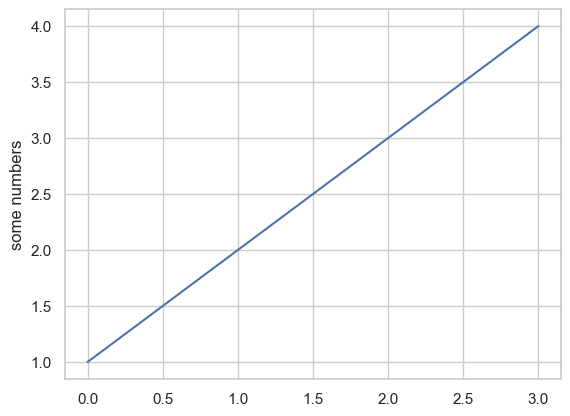

In [423]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4])
plt.ylabel('some numbers')
plt.show()

In [411]:
import numpy as np

# Creating a 1D and 2D
arraymatrix_1d = np.array([1, 2, 3]) 
matrix_2d = np.array([[1, 2], [3, 4]]) 
# # Fast element-wise math (impossible with regular lists) 
doubled = arraymatrix_1d * 2  
doubled
matrix_2d
# # Output: 
# array([2, 4, 6])


array([[1, 2],
       [3, 4]])

In [422]:
# def plot_cell_counts(df):

#     sns.set_theme(style="whitegrid")

#     plt.figure(figsize=(10, 5))

#     sns.lineplot(
#         data=df,
#         x="Concentration",
#         y="Cell count",
#         hue="Cell type",
#         palette={
#             "Sensitive": "blue",
#             "Resistant": "red",
#             "Total": "black"
#         },
#         linewidth=2
#     )

#     plt.xlabel("Drug concentration")
#     plt.ylabel("Cell count")
#     plt.title("Cells vs Drug Concentration")

#     plt.xlim(0, 0.065)

#     plt.ylim(0, 7000)

#     plt.legend(title="Cell Type")

#     plt.tight_layout()
#     plt.show()

0.0
1.6196760647870427e-05
3.238704518192723e-05
4.8570857485508696e-05
6.474820143884893e-05
8.091908091908093e-05
9.708349980023972e-05
0.00011324146195326544
0.0001293929712460064
0.00014553803154322223
0.00016167664670658686
0.00017780882059469167
0.00019393455706304873
0.00021005385996409337
0.00022616673314718787
0.00024227318045862413
0.0002583732057416268
0.0002744668128363564
0.0002905540055799124
0.0003066347878063359
0.0003227091633466136
0.0003387771360286796
0.0003548387096774193
0.00037089388811467253
0.0003869426751592357
0.0004029850746268657
0.0004190210903302826
0.0004350507260791725
0.000451073985680191
0.0004670908729369657
0.00048310139165009934
Concentration      R      S         Total
  0.0000    152.5499    1066.2701    1218.8200
  0.0020    152.4313    1030.3318    1182.7632
  0.0040    152.3129    822.2729    974.5858
  0.0060    152.1947    494.9979    647.1925
  0.0080    152.0765    246.9201    398.9966
  0.0100    151.9585    122.9677    274.9262
  0.0120 

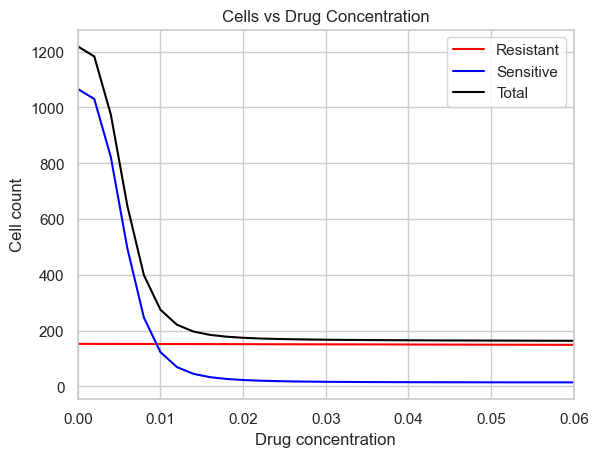

In [539]:
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

def cellCount(
    time,
    N0,
    phi,
    growth_rate_r,
    growth_rate_s,
    concentration,
    Emax_r,
    Emax_s,
    IC50_r,
    IC50_s,
    hill_slope_r,
    hill_slope_s
):
    def deathRate(
        concentration,
        Emax_r,
        Emax_s,
        IC50_r,
        IC50_s,
    ):
        #(self.Emax_r * C**self.Hill_r) / (C**self.Hill_r + self.IC50_r**self.Hill_r)
        DR_r = (Emax_r*concentration**hill_slope_r)/(concentration**hill_slope_r + IC50_r**hill_slope_r)
        DR_s = (Emax_s*concentration**hill_slope_s)/(concentration**hill_slope_s + IC50_s**hill_slope_s)
        return DR_r, DR_s
        

    DR_r, DR_s = deathRate(concentration,Emax_r,Emax_s, IC50_r,IC50_s)
    print (DR_r)
    #DR_s = deathRate(concentration, Emax_s, IC50_s)
    gNet_r = growth_rate_r - DR_r
    gNet_s = growth_rate_s - DR_s
   # print(gNet)
    R0 = N0 * phi
    S0 = N0 * (1-phi)
    R_t = R0 * math.exp(gNet_r * time)
    S_t = S0 * math.exp(gNet_s * time)
    N_t = R_t + S_t
    #print(N_t)
    
    return R_t, S_t, N_t

results = []

concentrations = np.linspace(0, 0.06, 31)
results = []
for concentration in concentrations:
    R_t, S_t, N_t = cellCount(48, 1000, 0.12, 0.005, 0.004, concentration, 0.081, 0.09, 10, 0.01, 1, 3)
    results.append([concentration, R_t, S_t, N_t])


# times = np.linspace(0, 48, 25)
# results = []
# for time in times:
#     R_t, S_t, N_t = cellCount(time, 1000, 0.12, 0.005, 0.004, concentration, 0.081, 0.09, 10, 0.01, 1, 3)
#     results.append([time, R_t, S_t, N_t])

# print(concentrations, times)

#results = np.array(results)

print("Concentration      R      S         Total")

for concentration, R_t, S_t, N_t in results:
    print(f"{(concentration):8.4f}    {R_t:8.4f}    {S_t:8.4f}    {N_t:8.4f}")


results = np.array(results)

concentration = results[:, 0]
R_t = results[:, 1]
S_t = results[:, 2]
N_t = results[:, 3]

plt.plot(concentration, R_t, label="Resistant", color = "red")
plt.plot(concentration, S_t, label="Sensitive", color = "blue")
plt.plot(concentration, N_t, label="Total", color = "black")

plt.xlabel("Drug concentration")
plt.ylabel("Cell count")
plt.title("Cells vs Drug Concentration")

plt.xlim(0, 0.06)





plt.legend()
plt.grid(True)
plt.show()

# np.set_printoptions(formatter={'float': lambda x: f"{x:10.4f}"})

#print(results)

# for concentration in range (0,10,1):
#     #print ()
#     cellCountX= cellCount(12, 100, 0.081, concentration*0.1, 1, 0.5)
#     # print (DR)
#     #print (concentration*0.1,DR,cellCountX)
    
# results.append(cellCountX)


# plt.plot(results)
# plt.xlabel('concentration')
# plt.title("Cell count vs. concentration")
# plt.ylabel('cell count')
# plt.show()


In [344]:
def deathRate(
    concentration,
    Emax,
    IC50
):
    DR = (Emax*concentration)/(concentration + IC50)

    return DR

deathRate(0.05, 0.1, 0.09) 

0.03571428571428572

In [337]:
# export const deriveInitialConditions = ({
# 	N0,
# 	phi,
# 	growthResistant,
# 	deathResistant,
# 	growthSensitive,
# 	deathSensitive
# }: DeriveInitialConditionsParams) => {
# 	const R0 = N0 * phi;
# 	const S0 = N0 - R0;
# 	const gNetR = growthResistant - deathResistant;
# 	const gNetS = growthSensitive - deathSensitive;

# 	return {
# 		R0,
# 		S0,
# 		gNetR,
# 		gNetS
# 	};
# };

def deriveInitialConditions(
    N0, 
    phi,
	growthResistant,
	deathResistant,
	growthSensitive,
	deathSensitive
):
    if phi < 0:
        phi = 0
    
    if phi > 1:
        phi = 1
    
    R0 = N0 * phi
    S0 = N0 - R0
    gNetR = growthResistant - deathResistant
    gNetS = growthSensitive - deathSensitive
    
    return R0, S0, gNetR, gNetS

# deriveInitialConditions TESTS
# it calculates the correct initial populations
test_N_0 = 1000
test_phi = 0.3
test_growth_R = 0.5
test_death_R = 0.5
test_growth_S = 0.5
test_death_S = 0.5

want_R_0 = 300
want_S_0 = 700

R0, S0, _, _ = deriveInitialConditions(test_N_0, test_phi, test_growth_R, test_death_R, test_growth_S, test_death_S)

assert want_R_0 == R0, f"wrong R0. Wanted: {want_R_0} Got: {R0}"
assert want_S_0 == S0, f"wrong S0. Wanted: {want_S_0} Got: {S0}"

# it disregards phi above 1
test_N_0 = 1000
test_phi = 1.3
test_growth_R = 0.5
test_death_R = 0.5
test_growth_S = 0.5
test_death_S = 0.5

want_R_0 = 1000
want_S_0 = 0

R0, S0, _, _ = deriveInitialConditions(test_N_0, test_phi, test_growth_R, test_death_R, test_growth_S, test_death_S)

assert want_R_0 == R0, f"wrong R0. Wanted: {want_R_0} Got: {R0}"
assert want_S_0 == S0, f"wrong S0. Wanted: {want_S_0} Got: {S0}"

# it disregards phi below 0
test_N_0 = 1000
test_phi = -0.3
test_growth_R = 0.5
test_death_R = 0.5
test_growth_S = 0.5
test_death_S = 0.5

want_R_0 = 0
want_S_0 = 1000

R0, S0, _, _ = deriveInitialConditions(test_N_0, test_phi, test_growth_R, test_death_R, test_growth_S, test_death_S)

assert want_R_0 == R0, f"wrong R0. Wanted: {want_R_0} Got: {R0}"
assert want_S_0 == S0, f"wrong S0. Wanted: {want_S_0} Got: {S0}"

[]


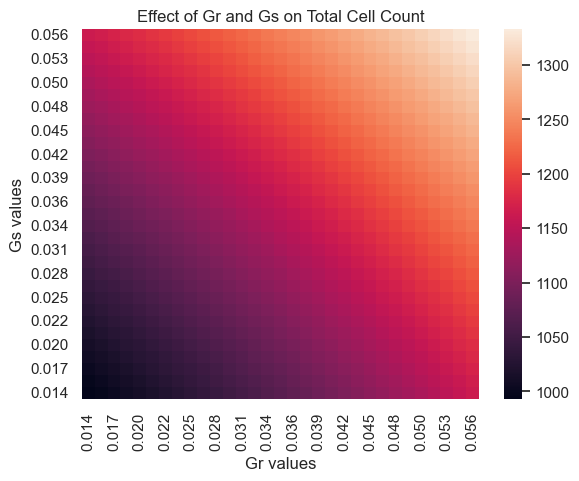

In [404]:
# imports
import math
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Constants
doubling_rate = 24
growth_constant = math.log(2)/doubling_rate
growth_rate_R = growth_constant
growth_rate_S = growth_constant
IC50_R = 5
Emax_R = 0.03
Concentration = 5
t = 7
phi = 0.5 # fraction resistant
N_0 = 1000

# Death rates
death_rate_R = (Emax_R*Concentration)/(Concentration + IC50_R)
death_rate_S = (Emax_S*Concentration)/(Concentration + IC50_S)


R_0, S_0, g_net_R, g_net_S = deriveInitialConditions(N_0, phi, growth_rate_R, death_rate_R, growth_rate_S, death_rate_S)

R_t = R_0*math.exp(g_net_R*t)
S_t = S_0*math.exp(g_net_S*t)
# R_t

# # Time sweep
# times = [0, 6, 12, 18, 24]
# R_results = []
# for time in times:
#     R_t = R_0*math.exp(g_net_R*time)
#     R_results.append(R_t)
#     # do this for sensitive

# R_results

#phi sweep
# phi_values = [0.02, 0.04, 0.06, 0.08, 0.1]
# R_results = []
# for phi in phi_values:
#     R_0 = N_0*phi
#     S_0 = N_0 - R_0

#     R_t = R_0*math.exp(g_net_R*t)
#     R_results.append(R_t)

# R_results

#Phi and growth rate R
growth_rate_S_values = np.linspace(0.014, 0.056, 31)[::-1]
growth_rate_R_values = np.linspace(0.014, 0.056, 31)
total_cells_heatmap = np.zeros(
    (len(growth_rate_S_values),len(growth_rate_R_values))
)
R_results = []
S_results = []
for i,growth_rate_S_value in enumerate(growth_rate_S_values):
    for j,growth_rate_R_value in enumerate(growth_rate_R_values):
        R_0 = N_0*phi
        S_0 = N_0 - R_0
        

        g_net_R = growth_rate_R_value - death_rate_R
        R_t = R_0*math.exp(g_net_R*t)
        

        g_net_S = growth_rate_S_value - death_rate_S
        S_t = S_0*math.exp(g_net_S*t)

        total_cells = S_t + R_t
        total_cells_heatmap[i,j]= total_cells
        # total_cells_results.append(total_cells)


df=pd.DataFrame(total_cells_heatmap, index=growth_rate_S_values,columns=growth_rate_R_values)
# df.head()
ax=sns.heatmap(df)
ax.set_xlabel("Gr values")
ax.set_ylabel("Gs values")
ax.set_title("Effect of Gr and Gs on Total Cell Count")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{growth_rate_R_values[int(x)]:.3f}")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{growth_rate_S_values[int(y)]:.3f}")
)

plt.show()

0.028881132523331052

In [4]:
# Constants
doubling_rate = 24
growth_constant = math.log(2)/doubling_rate
growth_rate_S = growth_constant
IC50_S = 5
Emax_S = 0.03
Concentration = 5
t = 7
fs = 1-phi
N_0 = 1000

# Initial populations
R_0 = N_0*phi
S_0 = N_0-R_0

# Death rates
death_rate_S = (Emax_S*Concentration)/(Concentration + IC50_S)

# Net growth rates
g_net_S = growth_rate_S - death_rate_S

S_t = S_0*math.exp(g_net_S*t)
# S_t

# Time sweep
times = [0, 6, 12, 18, 24]
S_results = []
for time in times:
    S_t = S_0*math.exp(g_net_S*time)
    S_results.append(S_t)
    # do this for sensitive

S_results

[950.0,
 1032.510794740044,
 1122.18793816286,
 1219.653852505501,
 1325.585019534959]

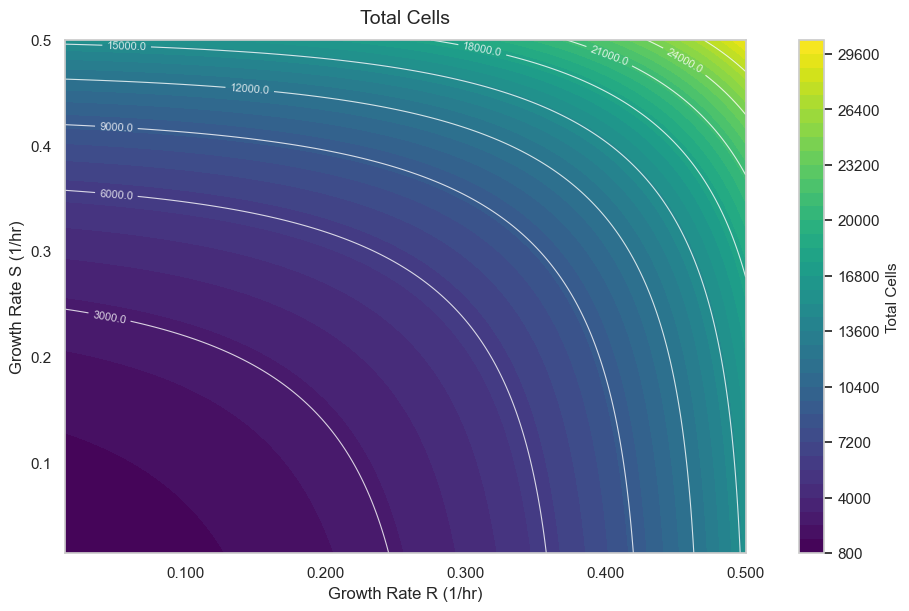

In [311]:
# imports
import math
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt

# Constants
doubling_rate = 24
growth_constant = math.log(2)/doubling_rate
growth_rate_R = growth_constant
IC50_R = 5
Emax_R = 0.03
Concentration = 5
t = 7
phi = 0.5 # fraction resistant
N_0 = 1000

# Death rates
death_rate_R = (Emax_R*Concentration)/(Concentration + IC50_R)
death_rate_S = (Emax_S*Concentration)/(Concentration + IC50_S)


R_0, S_0, g_net_R, g_net_S = deriveInitialConditions(N_0, phi, growth_rate_R, death_rate_R, growth_rate_S, death_rate_S)


R_t = R_0*math.exp(g_net_R*t)
S_t = S_0*math.exp(g_net_S*t)
# R_t

# # Time sweep
# times = [0, 6, 12, 18, 24]
# R_results = []
# for time in times:
#     R_t = R_0*math.exp(g_net_R*time)
#     R_results.append(R_t)
#     # do this for sensitive

# R_results

#phi sweep
# phi_values = [0.02, 0.04, 0.06, 0.08, 0.1]
# R_results = []
# for phi in phi_values:
#     R_0 = N_0*phi
#     S_0 = N_0 - R_0

#     R_t = R_0*math.exp(g_net_R*t)
#     R_results.append(R_t)

# R_results


# Growth rate R vs. Growth rate S
# title = "Total Cells"
# x_label = "Growth Rate R"
# y_label = "Growth Rate S"
# y_values = np.linspace(0.014, 0.056, 31) 
# x_values = np.linspace(0.014, 0.056, 31)




#Phi and growth rate R
title = "Total Cells"
x_label = "Growth Rate R (1/hr)"
y_label = "Growth Rate S (1/hr)"
x_values = np.linspace(0.014, 0.5, 31) 
y_values = np.linspace(0.014, 0.5, 31)
total_cells_heatmap = np.zeros(
    (len(y_values),len(x_values))
)
R_results = []
S_results = []
for i,y_value in enumerate(y_values):
    for j,x_value in enumerate(x_values):
        R_0 = N_0*phi
        S_0 = N_0 - R_0
        

        g_net_R = x_value - death_rate_R
        R_t = R_0*math.exp(g_net_R*t)
        

        g_net_S = y_value - death_rate_S
        S_t = S_0*math.exp(g_net_S*t)

        total_cells = S_t + R_t
        total_cells_heatmap[i,j]= total_cells
        # total_cells_results.append(total_cells)


df=pd.DataFrame(total_cells_heatmap, index=y_values,columns=x_values)

interp = RectBivariateSpline(
        y_values,
        x_values,
        total_cells_heatmap,
    )

antibody_fine = np.linspace(
    y_values.min(),
    y_values.max(),
    200,
)

wait_fine = np.linspace(
    x_values.min(),
    x_values.max(),
    200,
)

Z = interp(
    antibody_fine,
    wait_fine,
)

X, Y = np.meshgrid(wait_fine, antibody_fine)
fig, ax = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)



filled = ax.contourf(
    X,
    Y,
    Z,
    levels=40,
    cmap="viridis",
)

contours = ax.contour(
    X,
    Y,
    Z,
    levels=10,
    colors="white",
    linewidths=0.8,
    alpha=0.8,
)

ax.clabel(
    contours,
    inline=True,
    fontsize=8,
    fmt="%.1f",
)

cbar = fig.colorbar(
    filled,
    ax=ax,
)
cbar.set_label(
    "Total Cells",
    fontsize=11,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.3f}")
)

ax.set_xlabel(x_label)

ax.set_ylabel(
    y_label,
    fontsize=12,
)

ax.set_title(
    title,
    fontsize=14,
    pad=12,
)
# # df.head()
# ax=sns.heatmap(df,cmap="viridis")
# ax.set_xlabel("Gr values")
# ax.set_ylabel("Gs values")
# ax.set_title("Effect of Gr and Gs on Total Cell Count")

# ax.xaxis.set_major_formatter(
#     FuncFormatter(lambda x, pos: f"{growth_rate_R_values[int(x)]:.3f}")
# )

# ax.yaxis.set_major_formatter(
#     FuncFormatter(lambda y, pos: f"{growth_rate_S_values[int(y)]:.3f}")
# )

plt.show()

In [183]:
# unit tests
t_test=0

R_t_test = R_0 * math.exp(g_net_R * t_test)

assert R_t_test == R_0

print("t=0 test passed")

#initial populations
## resistant
R_0_expected = 500

assert R_0 == R_0_expected

print("R_0 test passed")

##sensitive

#S_0 = N_0 - R_0
S_0_expected = 500

assert S_0==S_0_expected


print("S_0 test passed")

#death rates

death_rate_R_expected = 0.015

#death_rate_R = (Emax_R*Concentration)/(Concentration+IC50_R)
assert death_rate_R_expected == death_rate_R
print ("death_rate_R test passed")

death_rate_S_expected = 0.015
assert death_rate_S_expected == death_rate_S
print("death_rate_S test passed")

t=0 test passed
R_0 test passed
S_0 test passed
death_rate_R test passed
death_rate_S test passed
